## MORISON STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

morison=pd.read_csv('../stock_data/morison.csv') ## so it can be small letter. This is cool.
morison=morison.drop(columns=['high_price','low_price'])
morison.rename(columns={'trade_date':'date'},inplace=True)
morison['date']=pd.to_datetime(morison['date'])
morison['month']=morison['date'].dt.month
morison['quarter']=morison['date'].dt.quarter
morison['year']=morison['date'].dt.year

morison

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42831,MORISON,2017-01-03,1.65,1.65,0.0,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43391,MORISON,2017-01-04,1.65,1.65,0.0,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43501,MORISON,2017-01-05,1.65,1.65,0.0,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43611,MORISON,2017-01-06,1.65,1.65,0.0,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43701,MORISON,2017-01-09,1.65,1.65,0.0,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298096,MORISON,2026-07-13,10.40,10.40,2082.0,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298534,MORISON,2026-07-14,10.40,10.40,2040.0,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298972,MORISON,2026-07-15,10.40,10.40,27032.0,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299410,MORISON,2026-07-16,10.40,10.40,15.0,2026-07-16T15:10:03.113936+00:00,7,3,2026


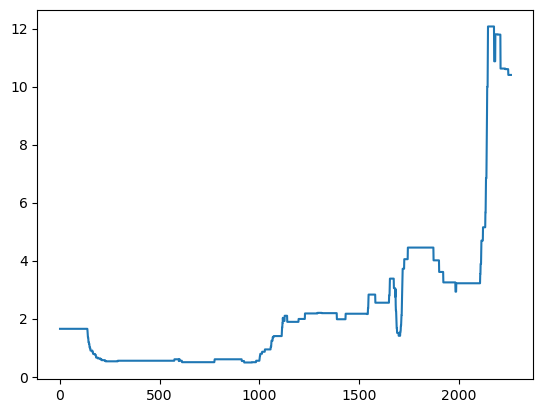

In [2]:
import matplotlib.pyplot as plt

plt.plot(morison['close_price'])
plt.show()

In [3]:
morison_end_month_df = (
    morison
    .sort_values("date")
    .groupby(morison["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

morison_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45401,MORISON,2017-01-31,1.65,1.65,0.0,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47223,MORISON,2017-02-28,1.65,1.65,100.0,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49339,MORISON,2017-03-31,1.65,1.65,0.0,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51166,MORISON,2017-04-28,1.65,1.65,0.0,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53089,MORISON,2017-05-31,1.65,1.65,0.0,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35333,MORISON,2026-03-31,11.80,11.80,25599.0,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281159,MORISON,2026-04-30,10.62,10.62,86450.0,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284225,MORISON,2026-05-29,10.62,10.62,16518.0,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294153,MORISON,2026-06-30,10.40,10.40,79163586.0,2026-06-30T15:10:03.08168+00:00,6,2,2026


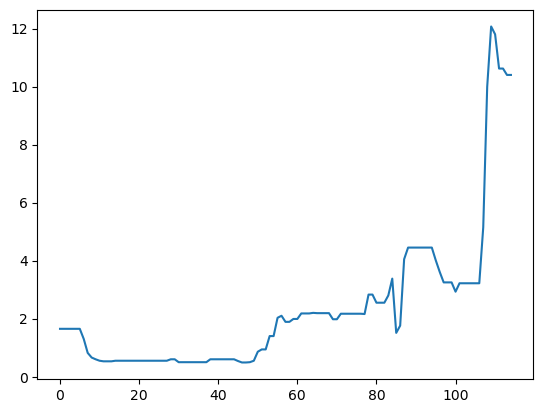

In [4]:
plt.plot(morison_end_month_df['close_price'])
plt.show()

In [5]:
morison_end_month_df['returns']=morison_end_month_df['close_price'].pct_change()*100
morison_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45401,MORISON,2017-01-31,1.65,1.65,0.0,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47223,MORISON,2017-02-28,1.65,1.65,100.0,2026-04-08T02:44:45.006295+00:00,2,1,2017,0.000000
2,49339,MORISON,2017-03-31,1.65,1.65,0.0,2026-04-08T02:45:42.281198+00:00,3,1,2017,0.000000
3,51166,MORISON,2017-04-28,1.65,1.65,0.0,2026-04-08T02:51:55.619599+00:00,4,2,2017,0.000000
4,53089,MORISON,2017-05-31,1.65,1.65,0.0,2026-04-08T02:52:57.421655+00:00,5,2,2017,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
110,35333,MORISON,2026-03-31,11.80,11.80,25599.0,2026-03-31T15:00:02.085058+00:00,3,1,2026,-2.236951
111,281159,MORISON,2026-04-30,10.62,10.62,86450.0,2026-04-30T15:00:02.170664+00:00,4,2,2026,-10.000000
112,284225,MORISON,2026-05-29,10.62,10.62,16518.0,2026-05-29T15:00:02.455558+00:00,5,2,2026,0.000000
113,294153,MORISON,2026-06-30,10.40,10.40,79163586.0,2026-06-30T15:10:03.08168+00:00,6,2,2026,-2.071563


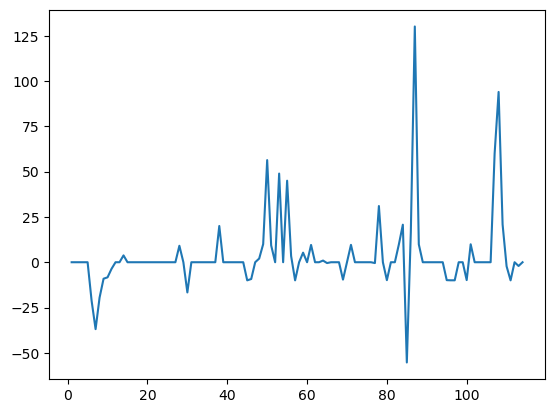

In [6]:
plt.plot(morison_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(morison_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(-7.634796700895016, 1.9653789072692785e-11, 1, 112, {'1%': -3.4901313156261384, '5%': -2.8877122815688776, '10%': -2.5807296460459184}, 886.726914857621)
stationary


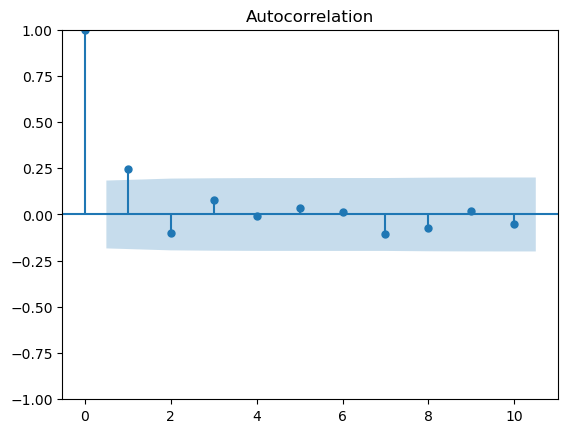

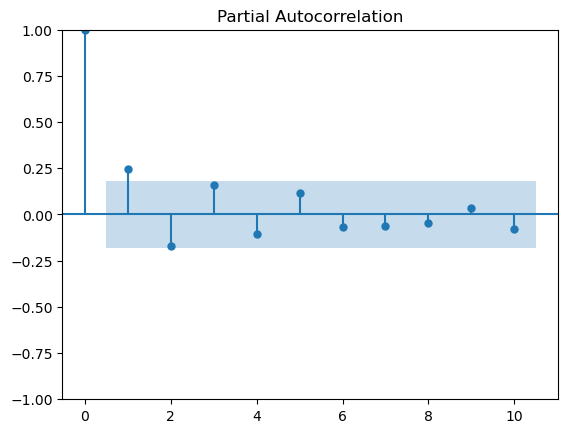

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(morison_end_month_df['returns'].dropna(), lags=10)
plot_pacf(morison_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=morison_end_month_df['close_price'][:-10]
test=morison_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -7.059843157024947]
[0, 0, 0, 0, 0, 1, -5.489146290835089]
[0, 0, 0, 0, 0, 2, -5.269056018104976]
[0, 0, 0, 0, 1, 0, -2.804378753640023]
[0, 0, 0, 0, 1, 1, -2.7989320719125454]
[0, 0, 0, 0, 1, 2, -2.692206116445946]
[0, 0, 0, 0, 2, 0, -3.1542848483901693]
[0, 0, 0, 0, 2, 1, -2.5860820926379327]
[0, 0, 0, 0, 2, 2, -2.523284353089555]
[0, 0, 0, 1, 0, 0, -3.0360204133040813]
[0, 0, 0, 1, 0, 1, -3.024823245923667]
[0, 0, 0, 1, 0, 2, -2.8969668811047105]
[0, 0, 0, 1, 1, 0, -2.7917454638334074]
[0, 0, 0, 1, 1, 1, -2.756942633507668]
[0, 0, 0, 1, 1, 2, -2.6800928884337654]
[0, 0, 0, 1, 2, 0, -2.187589885588858]
[0, 0, 0, 1, 2, 1, -2.1435488982681252]
[0, 0, 0, 1, 2, 2, -2.512852477817223]
[0, 0, 0, 2, 0, 0, -3.018778793601258]
[0, 0, 0, 2, 0, 1, -2.9898885644449926]
[0, 0, 0, 2, 0, 2, -2.923655532491452]
[0, 0, 0, 2, 1, 0, -2.5223416364051894]
[0, 0, 0, 2, 1, 1, -2.4524518304230263]
[0, 0, 0, 2, 1, 2, -2.6948768146906517]
[0, 0, 0, 2, 2, 0, -2.2234395500932305]
[0, 0, 0, 2,

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
168,0,2,0,0,2,0,-9.986352
411,1,2,0,0,2,0,-9.271347
465,1,2,2,0,2,0,-7.632063
222,0,2,2,0,2,0,-7.479164
438,1,2,1,0,2,0,-7.419501
...,...,...,...,...,...,...,...
178,0,2,0,1,2,1,-2.005211
417,1,2,0,1,1,0,-1.918302
174,0,2,0,1,1,0,-1.764970
186,0,2,0,2,2,0,-1.645999


Lets try the returns

In [11]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=morison_end_month_df['returns'].dropna()[:-10]
test=morison_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.2476263700390149]
[0, 0, 0, 0, 0, 1, -0.26442093325091687]
[0, 0, 0, 0, 0, 2, -0.2669041455969343]
[0, 0, 0, 0, 1, 0, -0.6332474396930174]
[0, 0, 0, 0, 1, 1, -0.3438582087618267]
[0, 0, 0, 0, 1, 2, -0.36924966402622195]
[0, 0, 0, 0, 2, 0, -3.0734839856961953]
[0, 0, 0, 0, 2, 1, -0.6880389404428813]
[0, 0, 0, 0, 2, 2, -0.8660722671841778]
[0, 0, 0, 1, 0, 0, -0.2640844550411925]
[0, 0, 0, 1, 0, 1, -0.27724447578663947]
[0, 0, 0, 1, 0, 2, -0.2632701709605898]
[0, 0, 0, 1, 1, 0, -1.1044849283350113]
[0, 0, 0, 1, 1, 1, -0.37015317529220026]
[0, 0, 0, 1, 1, 2, -0.3212858034763404]
[0, 0, 0, 1, 2, 0, -1.3025025472719474]
[0, 0, 0, 1, 2, 1, -1.242680860140923]
[0, 0, 0, 1, 2, 2, -0.8575146255193611]
[0, 0, 0, 2, 0, 0, -0.2645511368697253]
[0, 0, 0, 2, 0, 1, -0.27793844277003754]
[0, 0, 0, 2, 0, 2, -0.2645419935357487]
[0, 0, 0, 2, 1, 0, -0.5656373022221575]
[0, 0, 0, 2, 1, 1, -0.3660268093279171]
[0, 0, 0, 2, 1, 2, -0.34526968299514404]
[0, 0, 0, 2, 2, 0, -1.5431841064532

In [12]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
485,1,2,2,2,2,2,-1.471872e+10
411,1,2,0,0,2,0,-2.303175e+01
168,0,2,0,0,2,0,-1.173726e+01
653,2,2,0,0,2,0,-1.101338e+01
179,0,2,0,1,2,2,-1.032028e+01
...,...,...,...,...,...,...,...
378,1,1,2,0,0,0,-1.734752e-01
135,0,1,2,0,0,0,-1.722162e-01
108,0,1,1,0,0,0,-1.686232e-01
351,1,1,1,0,0,0,-1.684726e-01


Very horrible. We will work on this
